# Analysing Menstrual Cicles and Forecasting Periods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from pathlib import Path
import os
from datetime import datetime

In [2]:
def model_evaluation(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    accuracy = 1 - wape

    return {
        "MAE": mae,
        "RMSE": rmse,
        "r2": r2,
        "ACCURACY": accuracy,
    }


### Importing data

In [3]:
ROOT_PATH = Path(__name__).resolve().parent.parent
DATA_PATH = os.path.join(ROOT_PATH, "data", "menstrual_cycle_dataset_with_factors.csv")

In [4]:
df_complete = pd.read_csv(DATA_PATH)
df_complete.head()

,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps


### Data Treatment

In [5]:
df_complete.dtypes

User ID                    int64
Age                        int64
BMI                      float64
Stress Level               int64
Exercise Frequency           str
Sleep Hours              float64
Diet                         str
Cycle Start Date             str
Cycle Length               int64
Period Length              int64
Next Cycle Start Date        str
Symptoms                     str
dtype: object

In [6]:
df_complete["Cycle Start Date"] = pd.to_datetime(df_complete["Cycle Start Date"])
df_complete["Next Cycle Start Date"] = pd.to_datetime(df_complete["Next Cycle Start Date"])

df_complete["Cycle Start Date"] = df_complete["Cycle Start Date"].dt.normalize()
df_complete["Next Cycle Start Date"] = df_complete["Next Cycle Start Date"].dt.normalize()


In [7]:
new_columns = {c: c.lower().replace(" ", "_") for c in df_complete.columns}

df_complete = df_complete.rename(columns=new_columns)
df_complete.shape

(895, 12)

### Data Comprehension

In [8]:
df_complete.loc[df_complete["user_id"]==1]

,user_id,age,bmi,stress_level,exercise_frequency,sleep_hours,diet,cycle_start_date,cycle_length,period_length,next_cycle_start_date,symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13,26,7,2024-12-09,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09,32,5,2025-01-10,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10,41,7,2025-02-20,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20,27,3,2025-03-19,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19,42,5,2025-04-30,Cramps
5,1,18,29.28,2,Moderate,5.4,Low Carb,2025-04-30,41,5,2025-06-10,Fatigue
6,1,18,29.28,2,Moderate,5.4,Low Carb,2025-06-10,31,4,2025-07-11,Headache
7,1,18,29.28,2,Moderate,5.4,Low Carb,2025-07-11,48,7,2025-08-28,Fatigue
8,1,18,29.28,2,Moderate,5.4,Low Carb,2025-08-28,29,3,2025-09-26,Fatigue
9,1,18,29.28,2,Moderate,5.4,Low Carb,2025-09-26,47,4,2025-11-12,Headache


In [9]:
df_complete["cycle_start_date"] - df_complete["next_cycle_start_date"]

0     -26 days
1     -32 days
2     -41 days
3     -27 days
4     -42 days
        ...   
890   -35 days
891   -46 days
892   -49 days
893   -42 days
894   -40 days
Length: 895, dtype: timedelta64[us]

In [10]:
df_complete.columns

Index(['user_id', 'age', 'bmi', 'stress_level', 'exercise_frequency',
       'sleep_hours', 'diet', 'cycle_start_date', 'cycle_length',
       'period_length', 'next_cycle_start_date', 'symptoms'],
      dtype='str')

In [11]:
categorical_columns = [
    "stress_level", "exercise_frequency",
    "diet", "symptoms"
]

for c in categorical_columns:
    unique_values = df_complete[c].unique()

    print(f"\n{c}: {unique_values}  |  {len(unique_values)}")


stress_level: [2 4 1 5 3]  |  5

exercise_frequency: <ArrowStringArray>
['Moderate', 'Low', 'High']
Length: 3, dtype: str  |  3

diet: <ArrowStringArray>
['Low Carb', 'Vegetarian', 'Balanced', 'High Sugar']
Length: 4, dtype: str  |  4

symptoms: <ArrowStringArray>
['Headache', 'Fatigue', 'Cramps', 'Mood Swings', 'Bloating']
Length: 5, dtype: str  |  5


In [12]:
output_complete = {}

for c in categorical_columns:
    for i in sorted(df_complete[c].unique()):
        temp = df_complete.loc[df_complete[c]==i]
        
        output_complete[(c, str(i))] = {
            "average_age": round(temp["age"].mean(), 3),
            "median_age": temp["age"].median(),
            "average_sleep_hours": temp["sleep_hours"].median(),
            "diet_count": temp["diet"].value_counts(),
            "symptoms_count": temp["symptoms"].value_counts(),
        }

output_complete

{('stress_level', '1'): {'average_age': np.float64(29.366),
  'median_age': np.float64(26.0),
  'average_sleep_hours': np.float64(7.1),
  'diet_count': diet
  Balanced      74
  High Sugar    42
  Vegetarian    41
  Low Carb      26
  Name: count, dtype: int64,
  'symptoms_count': symptoms
  Headache       41
  Cramps         39
  Bloating       38
  Mood Swings    35
  Fatigue        30
  Name: count, dtype: int64},
 ('stress_level', '2'): {'average_age': np.float64(29.329),
  'median_age': np.float64(28.0),
  'average_sleep_hours': np.float64(7.3),
  'diet_count': diet
  Vegetarian    65
  Low Carb      45
  Balanced      40
  High Sugar     8
  Name: count, dtype: int64,
  'symptoms_count': symptoms
  Bloating       36
  Cramps         33
  Fatigue        32
  Mood Swings    29
  Headache       28
  Name: count, dtype: int64},
 ('stress_level', '3'): {'average_age': np.float64(32.748),
  'median_age': np.float64(35.0),
  'average_sleep_hours': np.float64(7.5),
  'diet_count': diet
 

### Data Preparation

In [13]:
df_dummies_raw = pd.get_dummies(df_complete, dtype="int")

In [14]:
def remove_unnecessary_columns(df: pd.DataFrame, cols_to_remove: list) -> pd.DataFrame:
    return df.loc[:, ~df.columns.isin(cols_to_remove)]


In [15]:
cols_to_remove = [
    "next_cycle_start_date"
]
df_dummies = remove_unnecessary_columns(df_dummies_raw, cols_to_remove)
df_dummies.head()

,user_id,age,bmi,stress_level,sleep_hours,cycle_start_date,cycle_length,period_length,exercise_frequency_High,exercise_frequency_Low,exercise_frequency_Moderate,diet_Balanced,diet_High Sugar,diet_Low Carb,diet_Vegetarian,symptoms_Bloating,symptoms_Cramps,symptoms_Fatigue,symptoms_Headache,symptoms_Mood Swings
0,1,18,29.28,2,5.4,2024-11-13,26,7,0,0,1,0,0,1,0,0,0,0,1,0
1,1,18,29.28,2,5.4,2024-12-09,32,5,0,0,1,0,0,1,0,0,0,1,0,0
2,1,18,29.28,2,5.4,2025-01-10,41,7,0,0,1,0,0,1,0,0,0,1,0,0
3,1,18,29.28,2,5.4,2025-02-20,27,3,0,0,1,0,0,1,0,0,0,1,0,0
4,1,18,29.28,2,5.4,2025-03-19,42,5,0,0,1,0,0,1,0,0,1,0,0,0


## Create Base Model

In [16]:
# df_base = df_dummies.copy()
# df_base["y"] = df_dummies.groupby(["user_id"])["cycle_length"].shift(1)
# df_base = df_base.dropna()
# df_base.head()

In [17]:
cols_drop_on_forecasting = ["user_id", "cycle_start_date"]

In [18]:
print("Min date: ", df_dummies["cycle_start_date"].min())
print("Max date: ", df_dummies["cycle_start_date"].max())

Min date:  2023-03-20 00:00:00
Max date:  2026-05-21 00:00:00


In [19]:
start_train = df_dummies["cycle_start_date"].min()

start_test = datetime(2026, 1, 1)
end_test = df_dummies["cycle_start_date"].max()

In [20]:
X_train = df_dummies.loc[(df_dummies["cycle_start_date"] >= start_train) & (df_dummies["cycle_start_date"] < start_test)]
X_test = df_dummies.loc[(df_dummies["cycle_start_date"] >= start_test) & (df_dummies["cycle_start_date"] < end_test)]

y_train = X_train["cycle_length"]
y_test = X_test["cycle_length"]

X_train = X_train.drop(cols_drop_on_forecasting + ["cycle_length"], axis=1)
X_test = X_test.drop(cols_drop_on_forecasting + ["cycle_length"], axis=1)

### Creating base model

In [21]:
model_v1 = LinearRegression()
model_v1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred_train = model_v1.predict(X_train)
y_pred_test = model_v1.predict(X_test)

In [23]:
print("Train Results")
model_evaluation(y_train, y_pred_train)

Train Results


{'MAE': 6.428468610822759,
 'RMSE': np.float64(7.443926205525043),
 'r2': 0.008573346653756198,
 'ACCURACY': np.float64(0.8278927902986962)}

In [24]:
print("Test Results")
model_evaluation(y_test, y_pred_test)

Test Results


{'MAE': 5.429332997616518,
 'RMSE': np.float64(6.611792958593049),
 'r2': 0.014423208552841738,
 'ACCURACY': np.float64(0.8595862155788832)}

In [25]:
X_comparison = X_test.copy()
X_comparison["cycle_length"] = y_test
X_comparison["y_base_model"] = y_pred_test

### Creating Tree Regressors Models

### Feature Engineering

In [26]:
def create_date_features(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df["cycle_start_date"][-1:].values[0], np.datetime64):

        df["day"] = df["cycle_start_date"].dt.day
        df["month"] = df["cycle_start_date"].dt.month
        df["year"] = df["cycle_start_date"].dt.year
        df["weekday"] = df["cycle_start_date"].dt.weekday
        df["weekend"] = [1 if d in [5, 6] else 0 for d in df["weekday"]]
    else:
        print("cycle_start_date -> IS NOT a datetime column")

    return df

In [27]:
def create_average_features(df: pd.DataFrame) -> pd.DataFrame:
    temp = df.groupby(["age"]).agg(
        {
            "bmi": "mean", "sleep_hours": "mean", 
            "cycle_length": "mean", "period_length": "mean"
    }
    ).reset_index()

    cols = {c: f"{c}_mean" for c in temp.columns if c != "age"}

    return pd.merge(
        left=df,
        right=temp.rename(columns=cols),
        on=["age"],
        how="left"
    )

In [28]:
df_dummies_v2 = df_dummies.copy()

df_dummies_v2 = create_date_features(df_dummies_v2)
df_dummies_v2 = create_average_features(df_dummies_v2)

In [29]:
df_dummies_v2.head()

,user_id,age,bmi,stress_level,sleep_hours,cycle_start_date,cycle_length,period_length,exercise_frequency_High,exercise_frequency_Low,...,symptoms_Mood Swings,day,month,year,weekday,weekend,bmi_mean,sleep_hours_mean,cycle_length_mean,period_length_mean
0,1,18,29.28,2,5.4,2024-11-13,26,7,0,0,...,0,13,11,2024,2,0,24.846061,6.393939,36.818182,5.30303
1,1,18,29.28,2,5.4,2024-12-09,32,5,0,0,...,0,9,12,2024,0,0,24.846061,6.393939,36.818182,5.30303
2,1,18,29.28,2,5.4,2025-01-10,41,7,0,0,...,0,10,1,2025,4,0,24.846061,6.393939,36.818182,5.30303
3,1,18,29.28,2,5.4,2025-02-20,27,3,0,0,...,0,20,2,2025,3,0,24.846061,6.393939,36.818182,5.30303
4,1,18,29.28,2,5.4,2025-03-19,42,5,0,0,...,0,19,3,2025,2,0,24.846061,6.393939,36.818182,5.30303


In [30]:
X_train_v2 = df_dummies_v2.loc[(df_dummies_v2["cycle_start_date"] >= start_train) & (df_dummies_v2["cycle_start_date"] < start_test)]
X_test_v2 = df_dummies_v2.loc[(df_dummies_v2["cycle_start_date"] >= start_test) & (df_dummies_v2["cycle_start_date"] < end_test)]

y_train_v2 = X_train_v2["cycle_length"]
y_test_v2 = X_test_v2["cycle_length"]

X_train_v2 = X_train_v2.drop(cols_drop_on_forecasting + ["cycle_length"], axis=1)
X_test_v2 = X_test_v2.drop(cols_drop_on_forecasting + ["cycle_length"], axis=1)

### RandomForestRegressor

In [31]:
params = {
    "n_estimators": [50, 100, 200, 300, 500, 800, 100, 1500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

In [32]:
estimator_v2 = RandomForestRegressor()

search_v2 = RandomizedSearchCV(
    estimator=estimator_v2, 
    param_distributions=params,
    n_iter=30,
    n_jobs=5,
    cv=10,
    verbose=1,
    random_state=1,
    scoring="neg_root_mean_squared_error"
)

search_v2.fit(X_train_v2, y_train_v2)

model_v2 = search_v2.best_estimator_

Fitting 10 folds for each of 30 candidates, totalling 300 fits


In [33]:
y_pred_train_v2 = model_v2.predict(X_train_v2)
y_pred_test_v2 = model_v2.predict(X_test_v2)

In [34]:
print("Train Results")
model_evaluation(y_train, y_pred_train_v2)

Train Results


{'MAE': 5.869658881518838,
 'RMSE': np.float64(6.823820285841919),
 'r2': 0.16687218700948003,
 'ACCURACY': np.float64(0.8428536136435472)}

In [35]:
print("Test Results")
model_evaluation(y_test, y_pred_test_v2)

Test Results


{'MAE': 5.057968967082312,
 'RMSE': np.float64(6.418243409306059),
 'r2': 0.07128097156837199,
 'ACCURACY': np.float64(0.8691904577478713)}

In [36]:
X_comparison["y_rfr_v2"] = y_pred_test_v2

In [37]:
def plot_feature_importance(model) -> None:
    features_importance = pd.DataFrame([dict(zip(model.feature_names_in_, model.feature_importances_))]).T
    features_importance = features_importance.reset_index().rename(columns={0: "importance", "index": "features"})
    features_importance = features_importance.sort_values(by="importance", ascending=True).reset_index(drop=True)

    plt.figure(figsize=(7, 10))
    plt.barh(features_importance["features"], features_importance["importance"])
    plt.title("Feature Importance")
    plt.show();

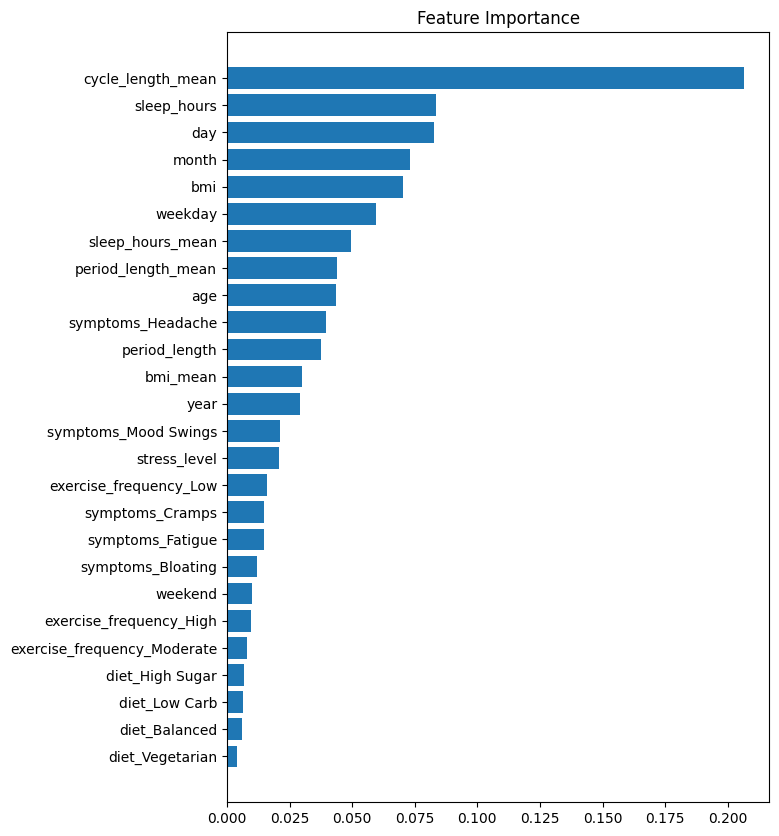

In [38]:
plot_feature_importance(model_v2)

In [39]:
def creating_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df["y_lag_1"] = df.groupby(["user_id"])["cycle_length"].shift(1)
    df["y_lag_2"] = df.groupby(["user_id"])["cycle_length"].shift(2)
    df["y_lag_3"] = df.groupby(["user_id"])["cycle_length"].shift(3)
    df["y_lag_6"] = df.groupby(["user_id"])["cycle_length"].shift(6)
 
    return df

In [40]:
df_dummies_v3 = creating_lag_features(df_dummies_v2)

In [41]:
X_train_v3 = df_dummies_v3.loc[(df_dummies_v3["cycle_start_date"] >= start_train) & (df_dummies_v3["cycle_start_date"] < start_test)]
X_test_v3 = df_dummies_v3.loc[(df_dummies_v3["cycle_start_date"] >= start_test) & (df_dummies_v3["cycle_start_date"] < end_test)]

y_train_v3 = X_train_v3["cycle_length"]
y_test_v3 = X_test_v3["cycle_length"]

X_train_v3 = X_train_v3.drop(cols_drop_on_forecasting + ["cycle_length"], axis=1)
X_test_v3 = X_test_v3.drop(cols_drop_on_forecasting + ["cycle_length"], axis=1)

In [42]:
estimator_v3 = RandomForestRegressor()

search_v3 = RandomizedSearchCV(
    estimator=estimator_v3, 
    param_distributions=params,
    n_iter=30,
    n_jobs=5,
    cv=10,
    verbose=1,
    random_state=1,
    scoring="neg_root_mean_squared_error"
)

search_v3.fit(X_train_v3, y_train_v3)

model_v3 = search_v3.best_estimator_

Fitting 10 folds for each of 30 candidates, totalling 300 fits


In [43]:
y_pred_train_v3 = model_v3.predict(X_train_v3)
y_pred_test_v3 = model_v3.predict(X_test_v3)

In [44]:
print("Train Results")
model_evaluation(y_train, y_pred_train_v3)

Train Results


{'MAE': 5.464136990214075,
 'RMSE': np.float64(6.375962229043581),
 'r2': 0.27264246334231,
 'ACCURACY': np.float64(0.8537105136940129)}

In [45]:
print("Test Results")
model_evaluation(y_test, y_pred_test_v3)

Test Results


{'MAE': 4.9227392938615635,
 'RMSE': np.float64(6.269516054823789),
 'r2': 0.11382393773737665,
 'ACCURACY': np.float64(0.8726877768828907)}

In [46]:
X_comparison["y_rfr_v3"] = y_pred_test_v3

In [47]:
X_comparison[["cycle_length", "y_rfr_v3"]]

,cycle_length,y_rfr_v3
126,35,38.366408
127,28,38.290961
254,43,38.936791
255,49,38.843922
364,33,37.956184
365,38,37.426505
366,28,37.503934
393,30,38.788300
621,40,40.173527
622,40,40.323273


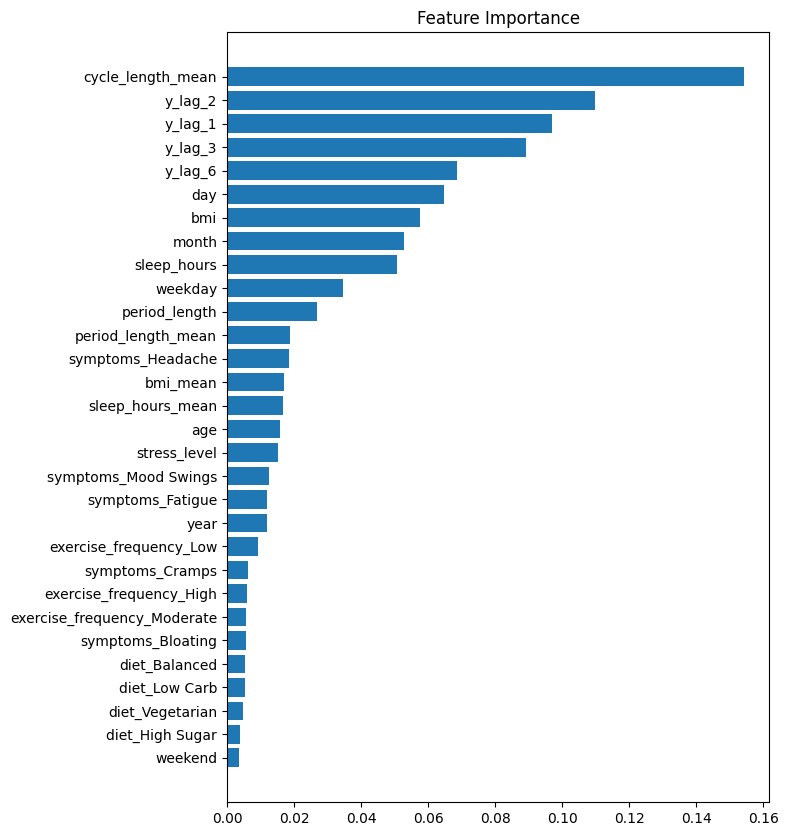

In [48]:
plot_feature_importance(model_v3)

### XGBoostRegressor

### LightGBMRegressor